In [2]:
import os
import signal

# The error message identified the zombie process as 3557
zombie_pid = 3557

try:
    # SIGKILL (Signal 9) tells the Mac OS to instantly terminate the process
    os.kill(zombie_pid, signal.SIGKILL)
    print(f"Target destroyed: Zombie process {zombie_pid} has been terminated.")
except ProcessLookupError:
    print(f"Process {zombie_pid} is already dead or not found.")
except PermissionError:
    print("You don't have permission to kill this process from here. Use Option B.")

Target destroyed: Zombie process 3557 has been terminated.


In [3]:
import duckdb
import pandas as pd
from sklearn.model_selection import train_test_split
import os

print("Loading data and engineering features...")

current_dir = os.getcwd()
db_path = os.path.join(current_dir, 'data', 'processed', 'tornado_database.duckdb')

# Connecting to our freed database!
conn = duckdb.connect(db_path, read_only=True)

df = conn.execute("""
    SELECT 
        BEGIN_LAT, 
        BEGIN_LON, 
        BEGIN_DATE_TIME
    FROM ef1_plus_tornadoes
""").fetchdf()

conn.close()

# 2. Clean and Engineer
df['BEGIN_DATE_TIME'] = pd.to_datetime(df['BEGIN_DATE_TIME'], format='mixed')
df = df.dropna(subset=['BEGIN_LON', 'BEGIN_LAT'])

df['MONTH'] = df['BEGIN_DATE_TIME'].dt.month
df['local_solar_hour'] = (df['BEGIN_DATE_TIME'].dt.hour + (df['BEGIN_LON'] / 15)) % 24
df['is_nocturnal'] = ((df['local_solar_hour'] >= 20) | (df['local_solar_hour'] <= 6)).astype(int)

# 3. Define Features (X) and Target (y)
X = df[['BEGIN_LAT', 'BEGIN_LON', 'MONTH']]
y = df['is_nocturnal']

# 4. The Data Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n--- Data Split Complete ---")
print(f"Total storms processed: {len(df)}")
print(f"Training the model on: {len(X_train)} storms")
print(f"Testing the model on: {len(X_test)} storms")

Loading data and engineering features...

--- Data Split Complete ---
Total storms processed: 42798
Training the model on: 34238 storms
Testing the model on: 8560 storms


Planting the Random Forest... (This might take 10-20 seconds)

--- Model Evaluation ---
               precision    recall  f1-score   support

  Daytime (0)       0.87      0.95      0.91      7199
Nocturnal (1)       0.49      0.24      0.32      1361

     accuracy                           0.84      8560
    macro avg       0.68      0.59      0.61      8560
 weighted avg       0.81      0.84      0.81      8560



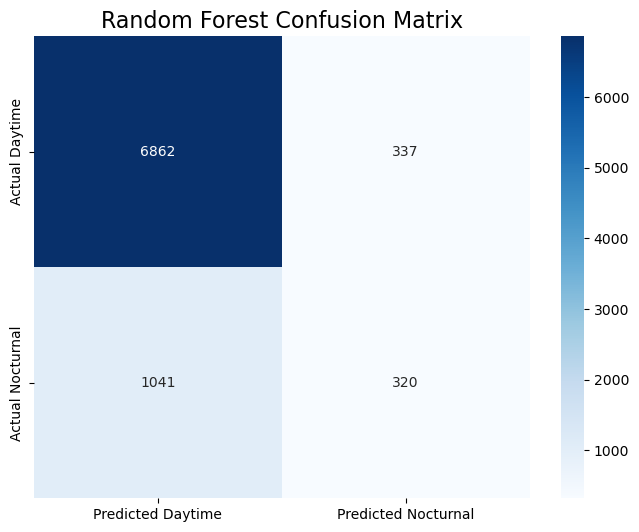

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Planting the Random Forest... (This might take 10-20 seconds)")

# 1. Initialize the Model
# 'class_weight=balanced' is an Architect-level move. 
# Since nocturnal tornadoes are rarer than daytime ones, this tells the 
# model to pay extra attention to the nighttime storms so it doesn't just guess "Daytime" every time.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# 2. Train the Model (The 'Study' Phase)
rf_model.fit(X_train, y_train)

# 3. Test the Model (The 'Final Exam')
y_pred = rf_model.predict(X_test)

# 4. Evaluate the Results
print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred, target_names=['Daytime (0)', 'Nocturnal (1)']))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Daytime', 'Predicted Nocturnal'],
            yticklabels=['Actual Daytime', 'Actual Nocturnal'])
plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.show()

Applying SMOTE to synthesize nocturnal storm patterns...
Original training targets: {0: 28586, 1: 5652}
SMOTE training targets: {1: 28586, 0: 28586}

Training the new SMOTE-enhanced Random Forest...

--- SMOTE Model Evaluation ---
               precision    recall  f1-score   support

  Daytime (0)       0.90      0.81      0.85      7199
Nocturnal (1)       0.34      0.51      0.41      1361

     accuracy                           0.77      8560
    macro avg       0.62      0.66      0.63      8560
 weighted avg       0.81      0.77      0.78      8560



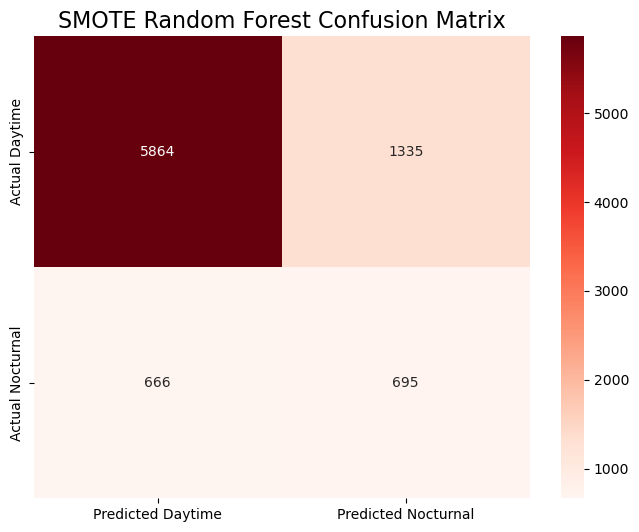

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Applying SMOTE to synthesize nocturnal storm patterns...")

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Resample ONLY the Training Data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training targets: {y_train.value_counts().to_dict()}")
print(f"SMOTE training targets: {y_train_smote.value_counts().to_dict()}")
print("\nTraining the new SMOTE-enhanced Random Forest...")

# 3. Train a new model on the balanced data
rf_smote_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote_model.fit(X_train_smote, y_train_smote)

# 4. Test the model on the UNTOUCHED Test Data
y_pred_smote = rf_smote_model.predict(X_test)

# 5. Evaluate the Results
print("\n--- SMOTE Model Evaluation ---")
print(classification_report(y_test, y_pred_smote, target_names=['Daytime (0)', 'Nocturnal (1)']))

# 6. Visualize the New Confusion Matrix
plt.figure(figsize=(8, 6))
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Daytime', 'Predicted Nocturnal'],
            yticklabels=['Actual Daytime', 'Actual Nocturnal'])
plt.title('SMOTE Random Forest Confusion Matrix', fontsize=16)
plt.show()

Extracting decision weights from the Random Forest...


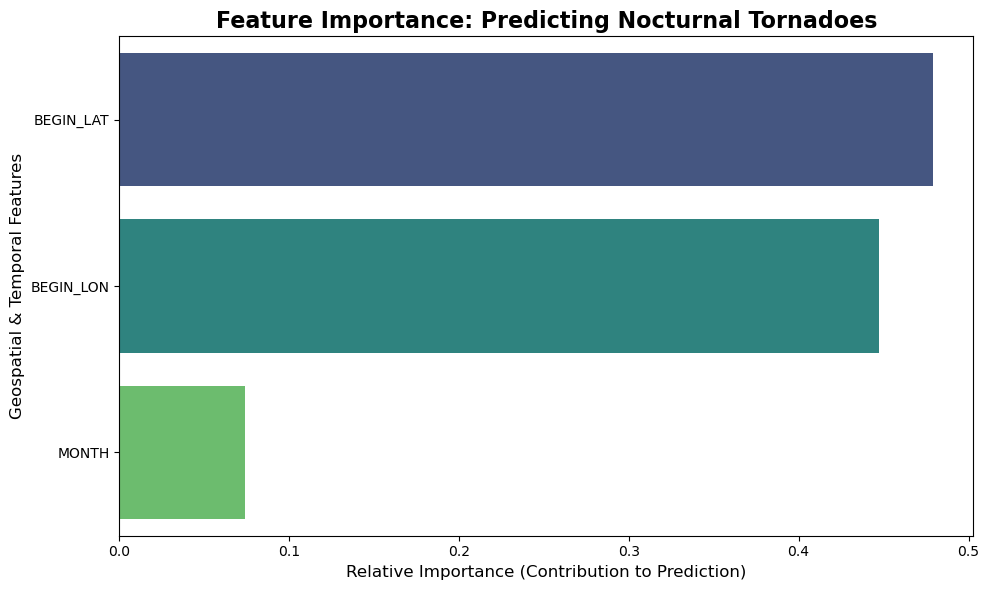

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting decision weights from the Random Forest...")

# 1. Extract feature importances from the SMOTE-trained model
importances = rf_smote_model.feature_importances_
features = X.columns

# 2. Create a DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Feature Importance (v0.14.0 Compliant)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    hue='Feature',          # <--- Added this
    palette='viridis', 
    legend=False            # <--- Added this
)

# 4. Professional Formatting
plt.title('Feature Importance: Predicting Nocturnal Tornadoes', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Prediction)', fontsize=12)
plt.ylabel('Geospatial & Temporal Features', fontsize=12)
plt.tight_layout()

# 5. Save the visual for your GitHub README!
plt.savefig('../visual_outputs/rf_feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()